# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [1]:
import pandas as pd

# try utf-8 first, fall back to latin-1 if there are decoding errors
try:
	df = pd.read_csv('DisneylandReviews.csv', encoding='utf-8')
except UnicodeDecodeError:
	df = pd.read_csv('DisneylandReviews.csv', encoding='latin-1')

df.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong


In [2]:
# split df by Branch into a dict of DataFrames
branch_dfs = {branch: group.reset_index(drop=True) for branch, group in df.groupby('Branch')}

# show available branches and counts
for branch, gdf in branch_dfs.items():
    print(f"{branch}: {len(gdf)} rows")

# Example: access Disneyland_Paris dataframe with branch_dfs['Disneyland_Paris']

Disneyland_California: 19406 rows
Disneyland_HongKong: 9620 rows
Disneyland_Paris: 13630 rows


In [3]:
# create dataset with only Disneyland_California reviews
df_california = branch_dfs['Disneyland_California'].copy()

# quick check
print(f"Rows: {len(df_california)}")
df_california.head()

Rows: 19406


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670801367,5,2019-4,United States,This place has always been and forever will be...,Disneyland_California
1,670760708,5,2019-4,United States,A great day of simple fun and thrills. Bring c...,Disneyland_California
2,670565072,4,2019-5,Australia,All and all a great day was had. The crowds ar...,Disneyland_California
3,670544335,5,2019-4,United States,Having been to the Florida location numerous t...,Disneyland_California
4,670472278,5,2019-4,Canada,"Had the 4 day pass, spent 3 at DL and one at C...",Disneyland_California


Getting just the Disneyland California reviews...

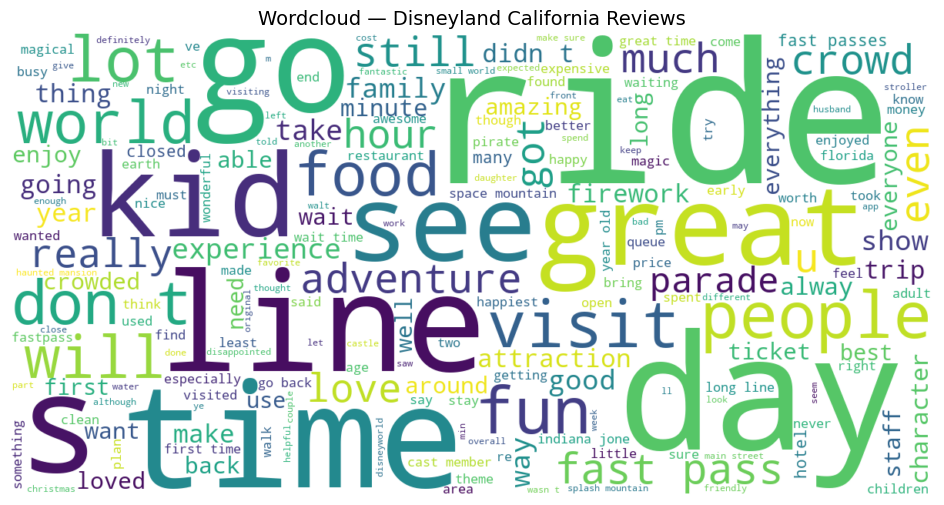

In [4]:
from wordcloud import WordCloud, STOPWORDS
import re

# Wordcloud for df_california reviews
import matplotlib.pyplot as plt

# Combine and clean text
text = " ".join(df_california['Review_Text'].astype(str).tolist())
text = text.lower()
text = re.sub(r'http\S+|www\S+|\d+', '', text)          # remove urls & numbers
text = re.sub(r'[^a-z\s]', ' ', text)                   # keep letters & spaces
text = re.sub(r'\s+', ' ', text).strip()

# Stopwords: base + domain-specific terms to reduce noise
stopwords = set(STOPWORDS)
stopwords.update(['disneyland', 'disney', 'park', 'parks', 'california', 'place', 'one', 'went', 'would'])

# Generate and display wordcloud
wc = WordCloud(width=1200, height=600, background_color='white',
               stopwords=stopwords, max_words=200).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud — Disneyland California Reviews', fontsize=14)
plt.show()

# Save image
wc.to_file('df_california_wordcloud.png')

With the word cloud, I was trying to see if I can gain insights into what is talked about the most. But as you can see, this doesn't really give us much clarity.

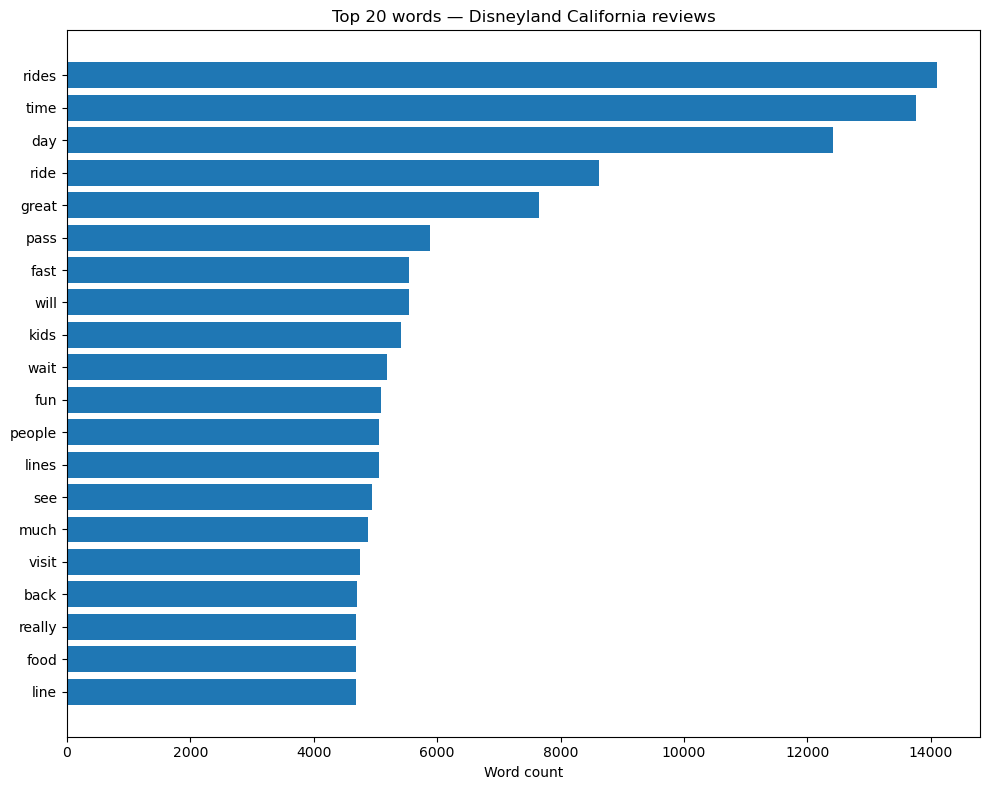

In [6]:
from collections import Counter
import numpy as np

# prepare cleaned text from df_california
texts = df_california['Review_Text'].astype(str).str.lower().tolist()
joined = " ".join(texts)
joined = re.sub(r'http\S+|www\S+|\d+', '', joined)
joined = re.sub(r'[^a-z\s]', ' ', joined)
joined = re.sub(r'\s+', ' ', joined).strip()

# use existing stopwords set if available
try:
    sw = stopwords
except NameError:
    sw = set(STOPWORDS)

# tokenize and count (ignore very short tokens)
tokens = [w for w in joined.split() if w not in sw and len(w) > 2]
counts = Counter(tokens)
top_n = 20
most_common = counts.most_common(top_n)
words, freqs = zip(*most_common)

# horizontal bar plot
plt.figure(figsize=(10, 8))
y = np.arange(len(words))
plt.barh(y, freqs, color='C0')
plt.gca().invert_yaxis()
plt.yticks(y, words)
plt.xlabel('Word count')
plt.title(f'Top {top_n} words — Disneyland California reviews')
plt.tight_layout()
plt.savefig('df_california_top_words_bar.png', dpi=150)
plt.show()

The bar graph gives us a much more concrete word count to try to dig deeper into the review content.

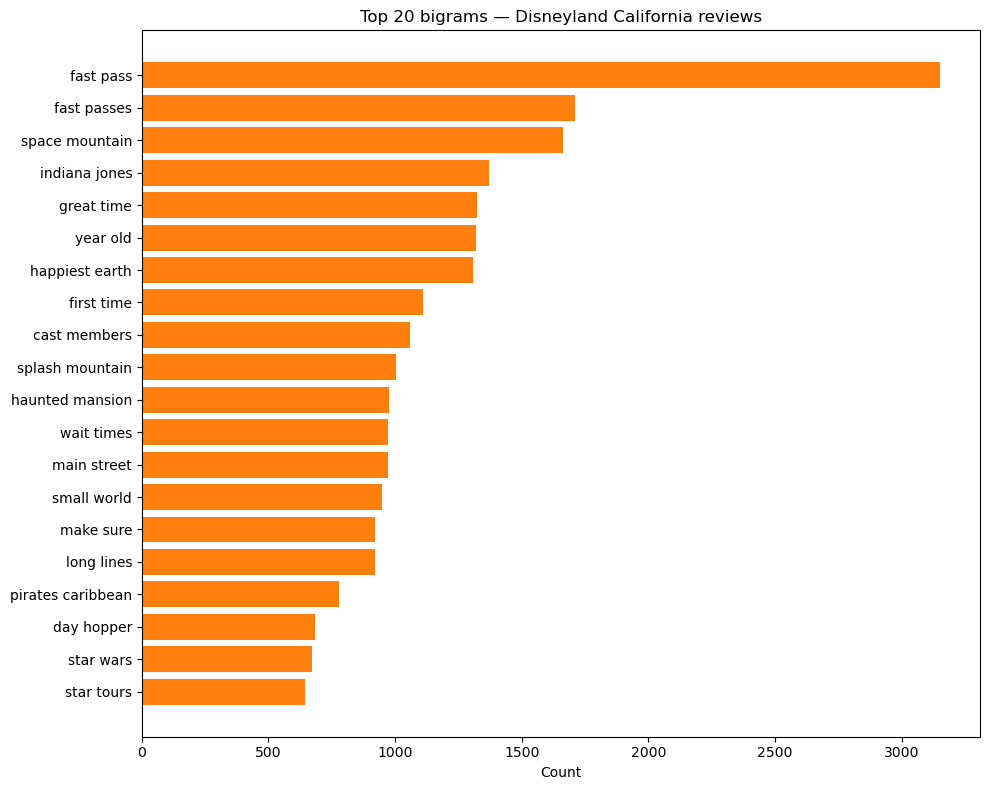

Interpretation: frequent bigrams (e.g., 'fast pass', 'wait time') surface common topics and operational pain points — useful for targeted improvements or deeper sentiment/topic analysis.


In [7]:
from collections import Counter

# Suggestions:
# - Sentiment distribution (polarity) histogram (TextBlob or VADER)
# - Topic modeling (LDA) + topic-word bar charts
# - Review length distribution (histogram + boxplot)
# - Bigram/trigram frequency bar chart (implemented below)
# The bigram chart highlights common two-word phrases (e.g., "fast pass", "wait time")
# which can reveal common complaints/praises and operational issues.


# reuse existing stopwords set if present
try:
    sw = stopwords
except NameError:
    try:
        sw = set(STOPWORDS)
    except NameError:
        sw = set()

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'http\S+|www\S+|\d+', '', s)
    s = re.sub(r'[^a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# build bigrams across reviews (only adjacent tokens within each review)
bigram_counts = Counter()
for txt in df_california['Review_Text'].astype(str):
    cleaned = clean_text(txt)
    toks = [w for w in cleaned.split() if w not in sw and len(w) > 2]
    bigrams = zip(toks, toks[1:])
    bigram_counts.update(bigrams)

top_n = 20
most_common_bigrams = bigram_counts.most_common(top_n)
bigrams_str = [' '.join(bg) for bg, _ in most_common_bigrams]
freqs = [f for _, f in most_common_bigrams]

# plot horizontal bar chart
plt.figure(figsize=(10, 8))
y = np.arange(len(bigrams_str))
plt.barh(y, freqs, color='C1')
plt.gca().invert_yaxis()
plt.yticks(y, bigrams_str)
plt.xlabel('Count')
plt.title(f'Top {top_n} bigrams — Disneyland California reviews')
plt.tight_layout()
plt.savefig('df_california_top_bigrams_bar.png', dpi=150)
plt.show()

# short interpretation printed
print("Interpretation: frequent bigrams (e.g., 'fast pass', 'wait time') surface common topics and operational pain points — useful for targeted improvements or deeper sentiment/topic analysis.")

Using Bigrams gives us so much more contextual background to the reviews. Here we can see major topics highlighted. "Make Sure" tells us there are a lot of people giving advice in their reviews, meaning it's probably recommended overall with some "guidance". Also, you can see that most of the topics discussed are actual ride names, which will help parents or people in general get an idea of what to expect on those rides.

Sentiment counts:
 vader_sentiment
positive    17320
neutral       361
negative     1725
Name: count, dtype: int64


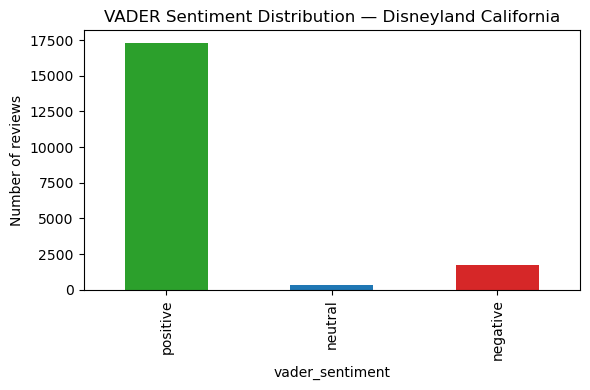

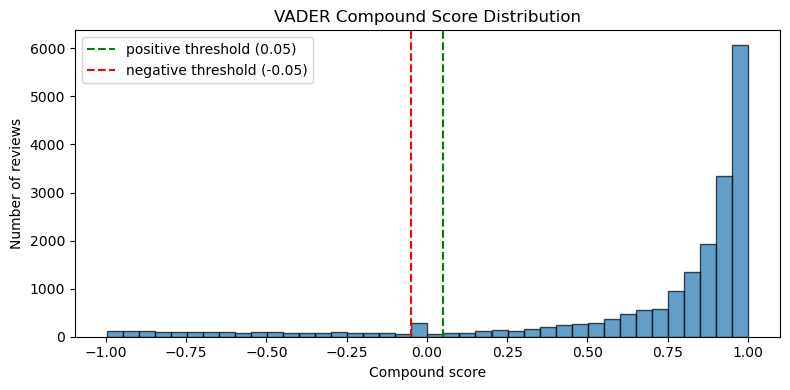


Top 5 positive reviews (by compound):


,vader_compound,Review_Text
13374,0.9999,"Doug s Disney Trip July 29 and July 30, 2013..."
11277,0.9999,I tried very hard to give Disneyland a lower r...
14304,0.9999,First of all let me say that this was not my f...
3241,0.9999,"There are 21,000 reviews of the Happiest Pla..."
10316,0.9998,"As a California native, I've been going to Dis..."



Top 5 negative reviews (by compound):


,vader_compound,Review_Text
8966,-0.9968,I am an avid Disney fan. I live in Texas but h...
18783,-0.9960,My husband and I went to Disneyland and Advent...
3078,-0.9941,I recently visited your Disneyland Theme Park ...
8129,-0.9939,"The park has gone WAY downhill lately, especia..."
12235,-0.9933,We took our 6 year old son to Disneyland (his ...


In [10]:
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure NLTK + VADER lexicon are available ---

try:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer

# Download lexicon only if needed
try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)

# Create analyzer
sia = SentimentIntensityAnalyzer()

# --- Compute scores ---
def vader_scores(text):
    return sia.polarity_scores(str(text))

scores = (
    df_california["Review_Text"]
    .fillna("")
    .astype(str)
    .apply(vader_scores)
    .tolist()
)
scores_df = pd.DataFrame(scores)

# Attach scores and simple label
df_california = df_california.reset_index(drop=True)

df_california[["vader_neg", "vader_neu", "vader_pos", "vader_compound"]] = scores_df[
    ["neg", "neu", "pos", "compound"]
]

conditions = [
    df_california["vader_compound"] >= 0.05,
    df_california["vader_compound"] <= -0.05
]
choices = ["positive", "negative"]
df_california["vader_sentiment"] = np.select(conditions, choices, default="neutral")

# Summary counts
sent_counts = (
    df_california["vader_sentiment"]
    .value_counts()
    .reindex(["positive", "neutral", "negative"])
    .fillna(0)
    .astype(int)
)
print("Sentiment counts:\n", sent_counts)

# Bar plot of sentiment distribution
plt.figure(figsize=(6, 4))
sent_counts.plot(kind="bar", color=["C2", "C0", "C3"])
plt.title("VADER Sentiment Distribution — Disneyland California")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.savefig("df_california_sentiment_counts.png", dpi=150)
plt.show()

# Histogram of compound scores
plt.figure(figsize=(8, 4))
plt.hist(df_california["vader_compound"], bins=40, color="C0", edgecolor="k", alpha=0.7)
plt.axvline(0.05, color="g", linestyle="--", label="positive threshold (0.05)")
plt.axvline(-0.05, color="r", linestyle="--", label="negative threshold (-0.05)")
plt.title("VADER Compound Score Distribution")
plt.xlabel("Compound score")
plt.ylabel("Number of reviews")
plt.legend()
plt.tight_layout()
plt.savefig("df_california_compound_hist.png", dpi=150)
plt.show()

# Show top positive and negative examples (display works in notebooks)
print("\nTop 5 positive reviews (by compound):")
display(df_california.sort_values("vader_compound", ascending=False)[["vader_compound", "Review_Text"]].head(5))

print("\nTop 5 negative reviews (by compound):")
display(df_california.sort_values("vader_compound", ascending=True)[["vader_compound", "Review_Text"]].head(5))

And here is a sentiment analysis of the Disneyland California reviews. There wasn't a sentiment column so this was assessed using NLTK and vader lexicon.
